# Storage ($G'$) and Loss ($G''$) Moduli

We can calculate the storage and loss moduli on the smooth $G(t)$ using (https://pubs.acs.org/doi/10.1021/acs.macromol.3c01893?ref=pdf)


$$G^\prime(\omega) = \omega \int_0^\infty G(t)\sin(\omega t) dt$$

$$G^{\prime\prime}(\omega) = \omega \int_0^\infty G(t)\cos(\omega t) dt$$


This evidently does not work. Due to the large values of $\omega t$, there is a significant amount of numeric instability. 

Let's instead use the implementation here (https://arxiv.org/pdf/2203.03752, appendix A).

$$\int_0^\infty G(t) \exp(-i\omega t)dt \approx $$
$$\sum_{k=1}^N \exp(-i\omega t_{k-1}) \left\{G_k \left( \frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{\exp(-i\omega \Delta t_k)}{i\omega} \right) - G_{k-1}\left(\frac{\exp(-i\omega\Delta t_k)-1}{\omega^2\Delta t_k} - \frac{1}{i\omega}\right)\right\}.$$

In [8]:
import numpy as np

def fourier_integral_moduli(t, G, omega):
    """
    Compute F(omega) = \int_0^\infty G(t) e^{-i omega t} dt
    using the discrete approximation
      sum_{k=1..N} exp(-i omega t_{k-1}) * { ... }  (as provided)
    Inputs:
      t     : 1D array of times, length M >= 2, increasing (t0..t_{M-1})
      G     : 1D array of G(t) values at those times (len == M)
      omega : scalar or 1D array of frequencies (rad/time)
    Returns:
      F    : complex array with shape (len(omega),) (or scalar if scalar omega)
      Gp   : real array G'(omega) = -omega * Im[F]
      Gpp  : real array G''(omega) =  omega * Re[F]
    Notes:
      - The formula assumes G is piecewise-defined on intervals [t_{k-1}, t_k].
      - For omega == 0 we fall back to trapezoidal integration.
    """
    t = np.asarray(t, dtype=float)
    G = np.asarray(G, dtype=float)
    if t.ndim != 1 or G.ndim != 1 or len(t) != len(G):
        raise ValueError("t and G must be 1D arrays of same length")

    omega_arr = np.atleast_1d(np.array(omega, dtype=float)) # make into a 1D array
    scalar_input = np.isscalar(omega)

    # segments: k = 1..N where N = M-1
    t_prev = t[:-1]         # t_{k-1}, shape (N,)
    dt = np.diff(t)         # Δt_k, shape (N,)
    G_prev = G[:-1]         # G_{k-1}
    G_k = G[1:]             # G_k

    if np.any(dt <= 0):
        raise ValueError("t must be strictly increasing")

    # prepare arrays for broadcasting
    W = omega_arr[:, None]          # shape (n_omega, 1)
    Tprev = t_prev[None, :]         # shape (1, N)
    DT = dt[None, :]                # shape (1, N)
    G_prev_mat = G_prev[None, :]    # shape (1, N)
    G_k_mat = G_k[None, :]          # shape (1, N)

    # handle omega == 0 separately
    # integral evaluates to simple trapezoidal integral of G(t)
    zero_mask = np.isclose(omega_arr, 0.0)
    F = np.zeros(omega_arr.shape, dtype=np.complex128)

    # 1) For zero-frequency entries use trapezoidal integral:
    if np.any(zero_mask):
        # simple trapezoid on original t/G
        F_zero = np.trapz(G, t)  # real
        F[zero_mask] = F_zero

    # 2) For non-zero omega, compute according to your discrete formula
    if np.any(~zero_mask):
        w_nz = omega_arr[~zero_mask]
        W_nz = w_nz[:, None]                 # (n_nz, 1)
        # compute exponentials
        exp_iw_dt = np.exp(-1j * W_nz * DT)  # shape (n_nz, N)
        exp_iw_tprev = np.exp(-1j * W_nz * Tprev)  # shape (n_nz, N)

        # avoid division by tiny omega^2 * dt or i*omega issues:
        # compute denominators
        w2 = (W_nz**2)            # shape (n_nz, 1)
        iw = 1j * W_nz            # shape (n_nz, 1)

        # compute the common piece (exp(-i w dt) - 1) / (w^2 dt)
        numer = (exp_iw_dt - 1.0)                     # (n_nz, N)
        denom = w2 * DT                               # (n_nz, N)
        # safe division - where denom is tiny, use Taylor expansion:
        small_mask = np.abs(denom) < 1e-16
        common = np.empty_like(numer, dtype=np.complex128)
        # safe division where denom not tiny
        ok = ~small_mask
        common[ok] = numer[ok] / denom[ok]
        # Taylor expansion for small x = w*dt: (e^{-i x}-1)/(w^2 dt)
        # numerator ~ -i x + (-x^2/2) + i(x^3/6) ...
        # (e^{-i x}-1)/(w^2 dt) ≈ (-i x - x^2/2 + ...)/(w^2 dt)
        # but x = w*dt so denominator w^2 dt = x^2/w => series simplifies;
        # The leading-order term: (-i w dt)/(w^2 dt) = -i / w
        # Next term: (- (w dt)^2/2)/(w^2 dt) = -dt/2
        # We'll use expansion up to O(dt)
        if np.any(small_mask):
            x = (W_nz * DT)[small_mask]  # small
            # compute approx: -i / w + (-DT/2) + O(w*dt)
            # note shapes align because small_mask selects elements
            approx = (-1j / W_nz[small_mask.any(axis=1)][:, None])  # shape hack - simpler compute elementwise below
            # Instead of trying to be too clever with shapes, compute elementwise fallback:
            it = np.nditer(small_mask, flags=['multi_index'])
            while not it.finished:
                i, j = it.multi_index  # i - omega index, j - segment index
                if small_mask[i, j]:
                    wval = W_nz[i, 0]
                    dtval = DT[0, j]
                    xval = wval * dtval
                    # series to O(dt)
                    common[i, j] = (-1j / wval) - 0.5 * dtval
                it.iternext()

        # compute the other denominators with iw
        # A = (exp(-i w dt) / (i w))
        # B = (1 / (i w))
        A = exp_iw_dt / (1j * W_nz)      # (n_nz, N)
        B = 1.0 / (1j * W_nz)            # (n_nz, 1) broadcasts

        # construct the bracketed expression for each segment:
        # term_k = G_k * ( common - exp(-i w dt) / (i w) )
        # minus G_{k-1} * ( common - 1/(i w) )
        term1 = G_k_mat * (common - A)
        term2 = G_prev_mat * (common - B)

        # full segment contributions (with exp(-i w t_{k-1}) factor)
        seg = exp_iw_tprev * (term1 - term2)   # shape (n_nz, N)

        # sum segments
        F_nz = np.sum(seg, axis=1)             # shape (n_nz,)
        # store back
        F[~zero_mask] = F_nz

    # final outputs: G' = -omega * Im(F), G'' = omega * Re(F)
    # ensure correct shape matching omega_arr
    Gp = -omega_arr * F.imag
    Gpp = omega_arr * F.real

    # return shapes consistent with input omega
    if scalar_input:
        return F[0], float(Gp[0]), float(Gpp[0])
    else:
        return F, Gp, Gpp


<>:4: SyntaxWarning: invalid escape sequence '\i'
<>:4: SyntaxWarning: invalid escape sequence '\i'
/tmp/ipykernel_1462629/3290729079.py:4: SyntaxWarning: invalid escape sequence '\i'
  """


# Testing simple exponential G(t) (Maxwell Model relaxation)

To verify the method above works, we will apply it to a Maxwell model (simple spring + dashpot model) and see if we get the expected storage and loss moduli.

The dynamic modulus of a simple Maxwell model is an exponential, with the form

$$G(t) = k e^{-\frac k \eta t}$$

and examining it in comparison to the expected form (https://pubs.rsc.org/en/content/articlehtml/2020/sm/d0sm00354a, Fig. 2)

False
Maxwell model G(t) min, max: 4.5399929762484854e-05 0.9048374180359595
Smallest and largest dt: 0.004761575278966479 0.45451543338165834


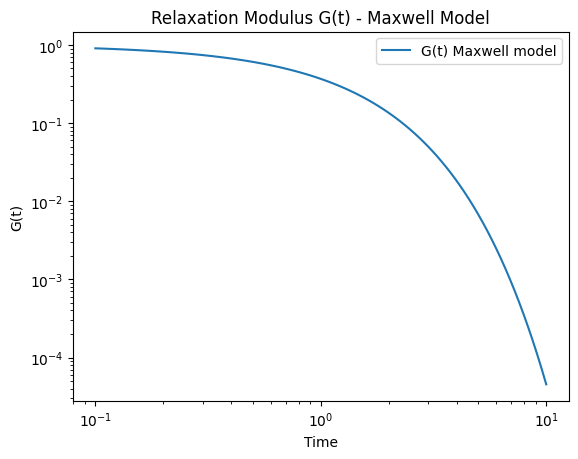

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Test of moduli function using a Maxwell model G(t) = k * exp(- (k/eta) * t)

k = 1
eta = 1.0
t = np.logspace(-1, 1, 100)
G_t = k * np.exp(- (k / eta) * t)

print(np.any(~np.isfinite(G_t))) # should be False
print("Maxwell model G(t) min, max:", G_t.min(), G_t.max())
print("Smallest and largest dt:", np.min(np.diff(t)), np.max(np.diff(t)))

# plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.loglog(t, G_t , label='G(t) Maxwell model')
plt.xlabel('Time')
plt.ylabel('G(t)')
plt.title('Relaxation Modulus G(t) - Maxwell Model')
plt.legend()
plt.show()



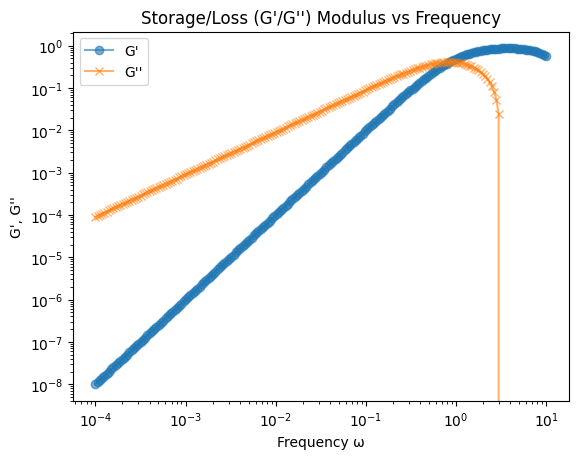

In [4]:
# t_start = 0
# t_end = 
# n data points
n = 200
omega = np.logspace(-4, 1, n)
F, Gp, Gpp = fourier_integral_moduli(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


Due to the log spacing of the multiple-tau output, I'm going to test a trapezoid integral. The calculation above is very unstable when $\Delta t$ gets large.

In [5]:
def fourier_moduli_uneven_vec(t, G, omega):
    t = np.asarray(t)
    G = np.asarray(G)
    omega = np.atleast_1d(omega)
    
    exp_matrix = np.exp(-1j * np.outer(omega, t))  # shape (len(omega), len(t))
    F = np.trapz(G * exp_matrix, t, axis=1)
    
    Gp = -omega * F.imag
    Gpp = omega * F.real
    return F, Gp, Gpp

/tmp/ipykernel_403925/4282204912.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  F = np.trapz(G * exp_matrix, t, axis=1)


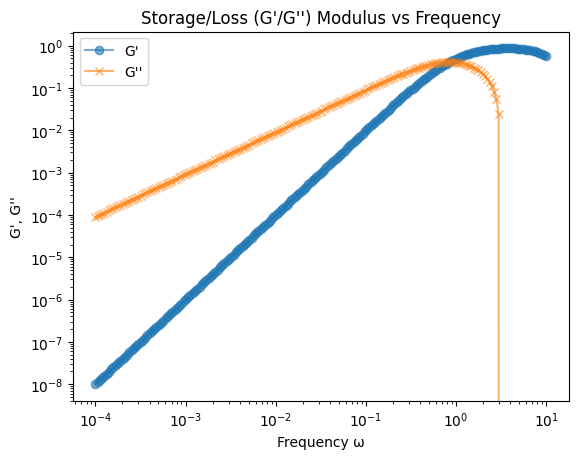

In [6]:

# n data points
n = 200
omega = np.logspace(-4, 1, n)
F, Gp, Gpp = fourier_moduli_uneven_vec(t, G_t, omega)
plt.loglog(omega, Gp, marker='o', alpha=0.6, label="G'")
plt.loglog(omega, Gpp, marker='x', alpha=0.6, label="G''")
plt.xlabel('Frequency ω')
plt.ylabel("G', G''")
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()


## Spacing list

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_Gt_vs_time():
    try:
        file = f"data/polymer_autocorr_long.dat"
        data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
        print(f"Processing file...")


        data = data[data['time'] >= t_start]
        data = data[data['time'] <= t_end]

        data["time"] *= 0.01

        G_t = (data['pxy'] + data['pxz'] + data['pyz']) / 5.0 + \
                (data['px_y'] + data['px_z'] + data['py_z']) / 30.0

        # replace negative with NaN
        # G_t = np.where(G_t < 0, np.nan, G_t)

        G_t *= 38.891111873282**3 / (1.0 * 1.0)  # V / (kB * T)

        plt.loglog(data['time'], G_t, alpha=0.5)
        # save file as space separated values
        output_file = f"data/processed_Gt_polymer.dat"
        processed_data = pd.DataFrame({'time': data['time'], 'G_t': G_t})
        processed_data.to_csv(output_file, sep=' ', index=False)
        print(f"Processed data saved to {output_file}")
    except FileNotFoundError:
        print(f"File not found.")

Processing file...
Processed data saved to data/processed_Gt_polymer.dat


/tmp/ipykernel_403925/2495291637.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


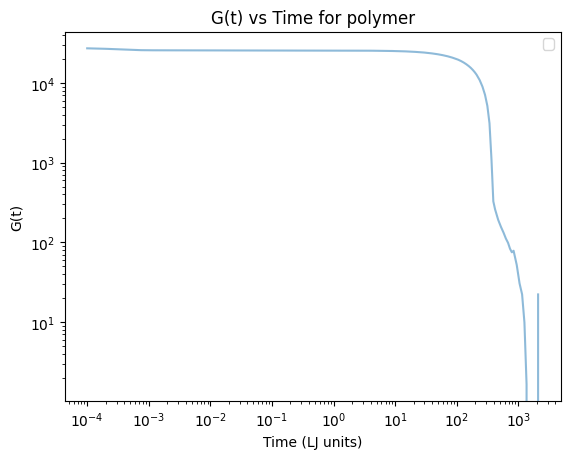

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# t_start = -np.inf
# t_end = np.inf
t_start = 0.01
t_end = 9e6

plot_Gt_vs_time()
x = np.linspace(t_start, t_end, 100)
# plt.loglog(x, x**-0.5, 'k--', label='Reference slope -0.5')

# plt.xlim([1e-1, t_end])
# plt.ylim([1e-1, 1e2])
plt.yscale('log')
plt.xlabel('Time (LJ units)')
plt.ylabel('G(t)')
plt.title('G(t) vs Time for polymer')
plt.legend()
plt.show()

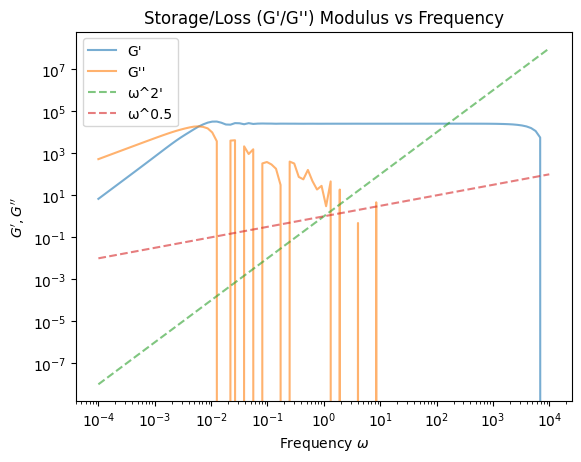

In [9]:
# apply fourier integral to each G(t) in G_list
storage_moduli = []
loss_moduli = []
n = 100
omega = np.logspace(-4, 4, n)

try:
    file = f"data/processed_Gt_polymer.dat"
    data = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time', 'G_t'])

    G_t = data['G_t'].values
    time = data['time'].values
    # print(len(time), len(G_t))
    # find NaN values and remove them
    mask = ~np.isnan(G_t)
    time = time[mask]
    G_t = G_t[mask]

    # zero pad G_t and time to next power of 2
    # N = len(G_t)
    # N_pad = 2**int(np.ceil(np.log2(N)))
    # G_t = np.pad(G_t, (0, N_pad - N), 'constant', constant_values=(0, 0))
    # time = np.pad(time, (0, N_pad - N), 'constant', constant_values=(0, time[-1] + (time[1]-time[0]) * np.arange(1, N_pad - N + 1)))  
    
except FileNotFoundError:
    print(f"File not found. Skipping.")

F, Gp, Gpp = fourier_integral_moduli(time, G_t, omega)
# print(len(omega), len(Gp), len(Gpp))
# print(Gp)
# storage_moduli.append(Gp)
# loss_moduli.append(Gpp)
plt.loglog(omega, Gp, linestyle='-', alpha=0.6, label=f"G'")
plt.loglog(omega, Gpp, linestyle='-', alpha=0.6, label=f"G''")

plt.loglog(omega, omega**2, linestyle='--', alpha=0.6, label=f"ω^2'")
plt.loglog(omega, omega**0.5, linestyle='--', alpha=0.6, label=f"ω^{0.5}")

plt.xlabel(r'Frequency $\omega$')
plt.ylabel("$G', G''$")
# plt.xlim([1e-4, 1e-1])
# plt.ylim([1e-11, 2e-6])
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.legend()
plt.show()

# Testing some autocorrelation stuff

Everything looks good, maybe it's worth just getting stress data and calculating autocorr myself

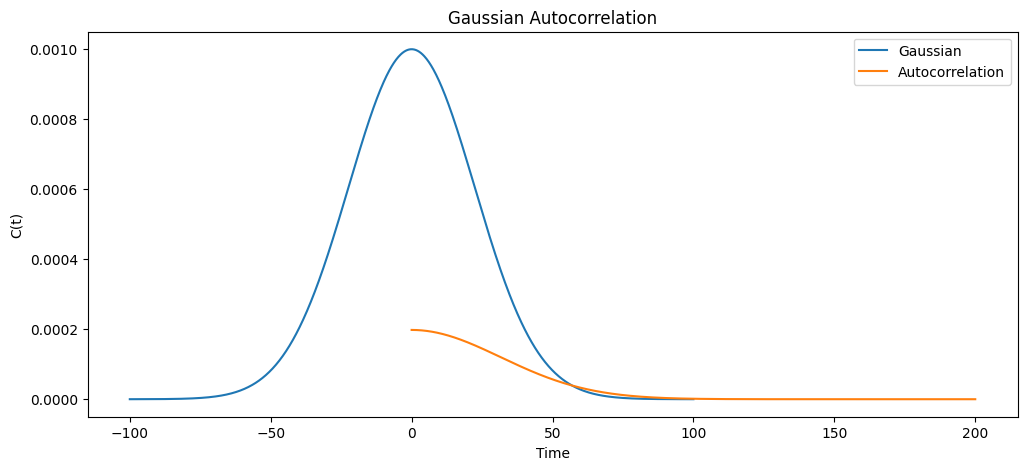

In [10]:
gaussian = lambda t, A, tau: A * np.exp(-t**2 / tau)

x = np.linspace(-100, 100, 1000)
y = gaussian(x, A=1e-3, tau=1e3)


def autocorr(x):
    result = np.correlate(x, x, mode='full')
    return result[result.size // 2:]

autocorr_gaussian = autocorr(y)

plt.figure(figsize=(12, 5))
plt.plot(x, y, label='Gaussian')
plt.plot(np.linspace(0, 200, 1000), autocorr_gaussian, label='Autocorrelation')
plt.xlabel('Time')
plt.ylabel('C(t)')
plt.legend()
plt.title('Gaussian Autocorrelation')
plt.show()

numpy autocorrelation took 0.3935 seconds
Scipy autocorrelation took 0.4609 seconds


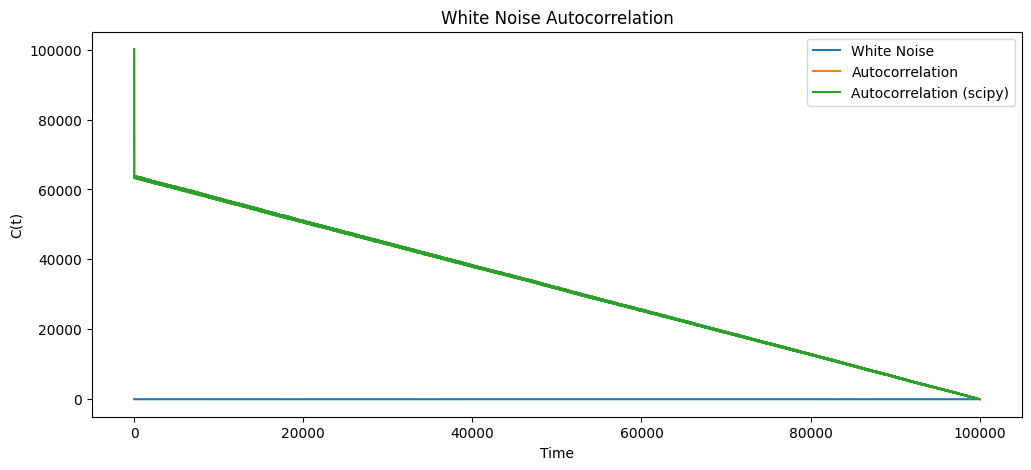

In [11]:
# white noise
import scipy
import time


x = np.linspace(0, 100000, 100000)
y = np.abs(np.random.normal(0, 1, size=x.shape))
start = time.time()
autocorr_noise = autocorr(y)
print(f"numpy autocorrelation took {time.time() - start:.4f} seconds")
start = time.time()
autocorr_noise_scipy = scipy.signal.correlate(y, y, mode='full')[len(y)-1:]
print(f"Scipy autocorrelation took {time.time() - start:.4f} seconds")

plt.figure(figsize=(12, 5))
plt.plot(x, np.abs(y), label='White Noise')
plt.plot(np.linspace(0, 100000, 100000), np.abs(autocorr_noise), label='Autocorrelation')
plt.plot(np.linspace(0, 100000, 100000), np.abs(autocorr_noise_scipy), label='Autocorrelation (scipy)')
plt.xlabel('Time')
plt.ylabel('C(t)')
plt.legend()
plt.title('White Noise Autocorrelation')
plt.show()

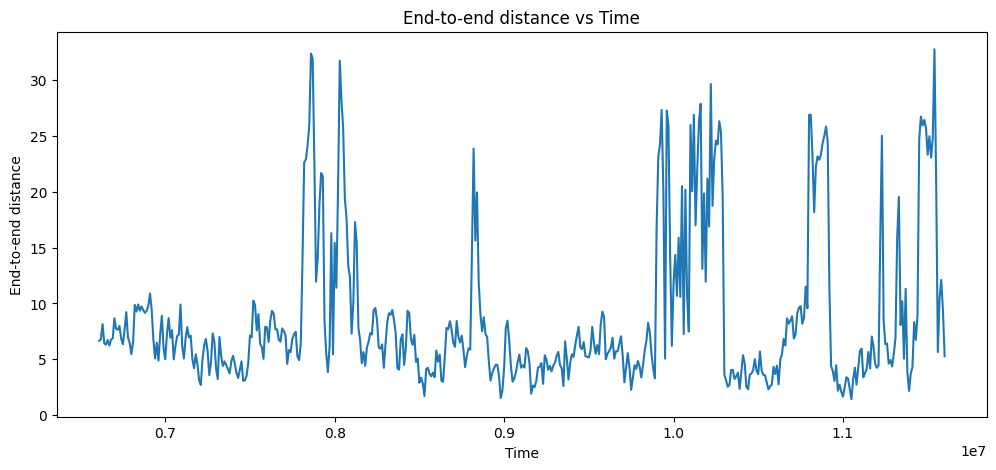

In [12]:
data = pd.read_csv("logs/endtoend_short.dat", skiprows=2, delimiter=" ", names=["time", "end2end"])

plt.figure(figsize=(12, 5))
plt.plot(data['time'], data['end2end'])
plt.xlabel('Time')
plt.ylabel('End-to-end distance')
plt.title('End-to-end distance vs Time')
plt.show()


## Let's try to calculate autocorr ourselves, instead of multiple tau, just to verify it 

(if they're obviously different, we need to take a closer look)

In [176]:
V = 30.450711080358**3
k_B = 1.0
T  = 1.0

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

data = pd.read_csv("data/pressure/prodpress_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125_langevin.dat", delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'p_x', 'p_y', 'p_z', 'p_xy', 'p_xz', 'p_yz'])
display(data.head())

data['time'] = (data['timestep'] - data['timestep'][0]) * 0.005

data['p_x-y'] = data['p_x'] - data['p_y']
data['p_x-z'] = data['p_x'] - data['p_z']
data['p_y-z'] = data['p_y'] - data['p_z']
display(data[-10:])

,timestep,press,p_x,p_y,p_z,p_xy,p_xz,p_yz
0,6600010,4.83124,4.77732,4.87083,4.84558,-0.002769,-0.027859,0.020741
1,6600020,4.99401,5.05969,4.99487,4.92746,-0.042850,-0.013521,0.019496
2,6600030,5.06111,5.00380,5.14095,5.03858,-0.021817,-0.007687,0.025229
3,6600040,4.90496,4.82166,5.06588,4.82733,0.044854,-0.020095,0.019531
4,6600050,4.85356,4.82253,4.90216,4.83598,-0.086804,-0.015016,-0.045572


,timestep,press,p_x,p_y,p_z,p_xy,p_xz,p_yz,time,p_x-y,p_x-z,p_y-z
4999990,56599910,4.98926,5.02948,4.96123,4.97709,-0.088656,0.002062,0.038091,249999.50,0.06825,0.05239,-0.01586
4999991,56599920,5.03946,5.09383,5.00821,5.01634,-0.034211,0.044088,-0.061539,249999.55,0.08562,0.07749,-0.00813
4999992,56599930,4.91911,4.95223,4.91167,4.89343,0.015305,-0.005126,0.014981,249999.60,0.04056,0.05880,0.01824
4999993,56599940,4.91084,4.84786,4.97037,4.91428,0.051075,0.017617,0.049763,249999.65,-0.12251,-0.06642,0.05609
4999994,56599950,4.97964,4.96085,4.96220,5.01587,-0.027208,0.053581,-0.001126,249999.70,-0.00135,-0.05502,-0.05367
4999995,56599960,4.99512,5.07323,4.94255,4.96960,0.037324,0.011543,0.054104,249999.75,0.13068,0.10363,-0.02705
4999996,56599970,4.97647,4.86656,4.96959,5.09327,0.051901,-0.000417,0.023664,249999.80,-0.10303,-0.22671,-0.12368
4999997,56599980,4.94517,4.93341,5.04157,4.86054,-0.054088,0.018084,-0.011855,249999.85,-0.10816,0.07287,0.18103
4999998,56599990,4.93357,4.94473,4.92594,4.93003,0.026940,0.017538,-0.055537,249999.90,0.01879,0.01470,-0.00409
4999999,56600000,4.94140,4.84835,4.96230,5.01355,-0.000609,-0.004794,-0.032686,249999.95,-0.11395,-0.16520,-0.05125


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal

data_no_langevin = pd.read_csv("data/pressure/prodpress_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.dat", delimiter=' ', skiprows=3, index_col=False, names=['timestep', 'press', 'p_x', 'p_y', 'p_z', 'p_xy', 'p_xz', 'p_yz'])
display(data_no_langevin.head())

# data['time'] = (data['timestep'] - data['timestep'][0]) * 0.005

data_no_langevin['p_x-y'] = data_no_langevin['p_x'] - data_no_langevin['p_y']
data_no_langevin['p_x-z'] = data_no_langevin['p_x'] - data_no_langevin['p_z']
data_no_langevin['p_y-z'] = data_no_langevin['p_y'] - data_no_langevin['p_z']
# display(data[-10:])

,timestep,press,p_x,p_y,p_z,p_xy,p_xz,p_yz
0,6600010,4.83071,4.77603,4.87046,4.84563,-0.001721,-0.027155,0.020628
1,6600020,4.99658,5.06095,4.99771,4.93108,-0.045334,-0.011999,0.018244
2,6600030,5.06289,5.00428,5.14581,5.03857,-0.020983,-0.009064,0.022585
3,6600040,4.90427,4.82064,5.06799,4.82419,0.044880,-0.016914,0.022033
4,6600050,4.85223,4.82039,4.90236,4.83393,-0.092491,-0.010588,-0.047434


In [179]:
def autocorr(x):
    # result = np.correlate(x, x, mode='full')
    # return result[result.size // 2:]
    return scipy.signal.correlate(x, x, mode='full')[len(x)-1:]

G_t_scipy = V / (k_B * T) * (autocorr(data['p_xy'].values) + autocorr(data['p_xz'].values) + autocorr(data['p_yz'].values)) / 5.0 + \
      V / (k_B * T) *(autocorr(data['p_x-y'].values) + autocorr(data['p_x-z'].values) + autocorr(data['p_y-z'].values)) / 30.0

G_t_scipy = np.where(G_t_scipy < 0, np.nan, G_t_scipy)
print(G_t_scipy[:10])


G_t_scipy_no_langevin = V / (k_B * T) * (autocorr(data_no_langevin['p_xy'].values) + autocorr(data_no_langevin['p_xz'].values) + autocorr(data_no_langevin['p_yz'].values)) / 5.0 + \
      V / (k_B * T) *(autocorr(data_no_langevin['p_x-y'].values) + autocorr(data_no_langevin['p_x-z'].values) + autocorr(data_no_langevin['p_y-z'].values)) / 30.0

G_t_scipy_no_langevin = np.where(G_t_scipy_no_langevin < 0, np.nan, G_t_scipy_no_langevin)
print(G_t_scipy_no_langevin[:10])


[3.33923530e+08            nan            nan 8.62485508e+07
            nan 1.76406147e+07            nan 8.66472266e+06
 1.30200057e+07            nan]
[3.42637246e+08            nan            nan 8.74529532e+07
            nan 1.79874332e+07            nan 8.80952163e+06
 1.30707023e+07            nan]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

V = 30.450711**3
k_B = 1.0
T  = 1.0

file = f"data/autocorrelation/prodautocorr_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125_langevin.dat"
data_multitau = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
G_t_multitau = V / (k_B * T) *  (data_multitau['pxy'] + data_multitau['pxz'] + data_multitau['pyz']) / 5.0 + \
                V / (k_B * T) * (data_multitau['px_y'] + data_multitau['px_z'] + data_multitau['py_z']) / 30.0

# replace negative values
G_t_multitau = G_t_multitau.where(G_t_multitau >= 0, np.nan)

file = f"data/autocorrelation/prodautocorr_chainlength_30_gaussA_50_r0_0.45_gaussB_13.8504255125.dat"
data_multitau_no_langevin = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
G_t_multitau_no_langevin = V / (k_B * T) *  (data_multitau_no_langevin['pxy'] + data_multitau_no_langevin['pxz'] + data_multitau_no_langevin['pyz']) / 5.0 + \
                V / (k_B * T) * (data_multitau_no_langevin['px_y'] + data_multitau_no_langevin['px_z'] + data_multitau_no_langevin['py_z']) / 30.0

# replace negative values
G_t_multitau_no_langevin = G_t_multitau_no_langevin.where(G_t_multitau_no_langevin >= 0, np.nan)

file = f"data/autocorrelation/prodautocorr_chainlength_30_N_beads_24000_gaussA_0_r0_0.35_gaussB_10_seed_12345.dat"
data_multitau_no_patches = pd.read_csv(file, delimiter=' ', skiprows=3, index_col=False, names=['time','px_y', 'px_z', 'py_z', 'pxy', 'pxz', 'pyz'])
G_t_multitau_no_patches = V / (k_B * T) *  (data_multitau_no_patches['pxy'] + data_multitau_no_patches['pxz'] + data_multitau_no_patches['pyz']) / 5.0 + \
                V / (k_B * T) * (data_multitau_no_patches['px_y'] + data_multitau_no_patches['px_z'] + data_multitau_no_patches['py_z']) / 30.0

# replace negative values
G_t_multitau_no_patches = G_t_multitau_no_patches.where(G_t_multitau_no_patches >= 0, np.nan)



In [5]:
# graph from Schmid paper with N=30 points extracted from their plot
data_schmid = pd.read_csv("data/g_t_n30.csv", names=['G_t', 'time'])
display(data_schmid.head())

,G_t,time
0,1.657352,0.469196
1,1.154304,0.674148
2,0.315360,3.851678
3,0.203903,7.859024
4,0.168334,10.626086


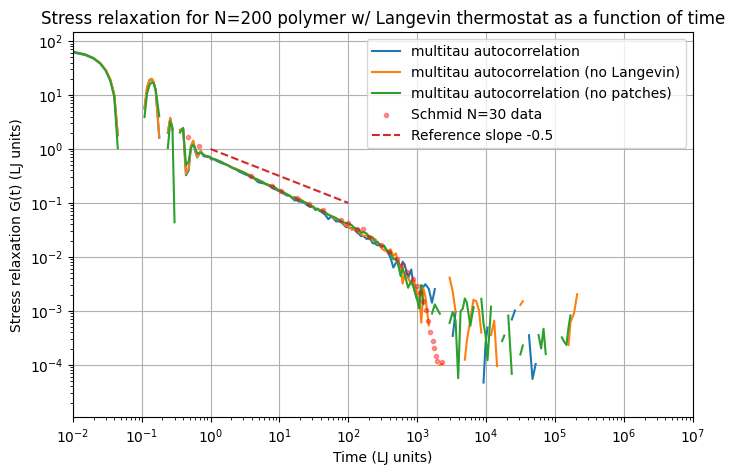

In [6]:
plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')
# normalize = lambda x: (x[0] + x[1] + x[2]) / 3
# plt.loglog(data['time'], G_t_scipy , label='scipy autocorrelation')
plt.loglog(data_multitau['time'], G_t_multitau , label='multitau autocorrelation')
# plt.loglog(data_multitau_short['time'], G_t_multitau_short , label='multitau autocorrelation (short)')
# plt.loglog(data_no_langevin['time'], G_t_scipy_no_langevin , label='scipy autocorrelation (no Langevin)')
plt.loglog(data_multitau_no_langevin['time'], G_t_multitau_no_langevin , label='multitau autocorrelation (no Langevin)')
plt.loglog(data_multitau_no_patches['time'], G_t_multitau_no_patches , label='multitau autocorrelation (no patches)')
plt.scatter(data_schmid['time'], data_schmid['G_t'], color='red', marker='.', label='Schmid N=30 data', alpha=0.4, zorder=10)
plt.loglog(np.logspace(0, 2), (np.logspace(0, 2))**-0.5, '--', label='Reference slope -0.5')
plt.xlabel('Time (LJ units)')
plt.ylabel('Stress relaxation G(t) (LJ units)')
plt.xlim([1e-2, 1e7])
# plt.ylim([1e-4,1e2])
plt.grid()
plt.title('Stress relaxation for N=200 polymer w/ Langevin thermostat as a function of time')
plt.legend()
plt.show()

[3.70287346e-05 4.25708814e-05 4.89419849e-05 5.62658592e-05
 6.46847554e-05 7.43620881e-05 8.54855603e-05 9.82707419e-05
 1.12965164e-04 1.29853003e-04] [0.00175456 0.00188121 0.00201699 0.00216253 0.00231855 0.00248577
 0.00266501 0.0028571  0.00306296 0.00328355]


<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:32: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1462629/2369101136.py:32: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")


,omega_Gpp,Gpp,omega_Gp,Gp
0,0.000122,0.002947,0.000150,0.000127
1,0.000147,0.003728,0.000181,0.000188
2,0.000178,0.004715,0.000219,0.000283
3,0.000215,0.005429,0.000268,0.000426
4,0.000270,0.006551,0.000326,0.000631


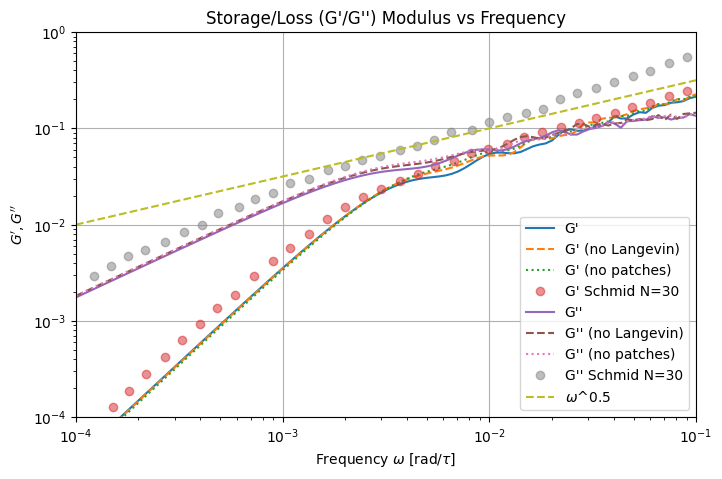

In [9]:
omega = np.logspace(-4, -1, 100)

prepped_G_t_multitau = G_t_multitau[(data_multitau['time'] > 1) & (data_multitau['time'] < 1000)].values
prepped_time = data_multitau['time'][(data_multitau['time'] > 1) & (data_multitau['time'] < 1000)].values
prepped_G_t_multitau_no_patches = G_t_multitau_no_patches[(data_multitau_no_patches['time'] > 1) & (data_multitau_no_patches['time'] < 1000)].values
prepped_time_no_patches = data_multitau_no_patches['time'][(data_multitau_no_patches['time'] > 1) & (data_multitau_no_patches['time'] < 1000)].values

prepped_G_t_multitau_no_langevin = G_t_multitau_no_langevin[(data_multitau_no_langevin['time'] > 1) & (data_multitau_no_langevin['time'] < 1000)].values
prepped_time_no_langevin = data_multitau_no_langevin['time'][(data_multitau_no_langevin['time'] > 1) & (data_multitau_no_langevin['time'] < 1000)].values

# fourier transform of G_t_multitau
_, Gp, Gpp = fourier_integral_moduli(prepped_time, prepped_G_t_multitau, omega)
_, Gp_no_langevin, Gpp_no_langevin = fourier_integral_moduli(prepped_time_no_langevin, prepped_G_t_multitau_no_langevin, omega)
print(Gp[:10], Gpp[:10])
_, Gp_no_patches, Gpp_no_patches = fourier_integral_moduli(prepped_time_no_patches, prepped_G_t_multitau_no_patches, omega)

file = "data/gpgpp_schmid_n30.csv"
data_schmid_gpgpp = pd.read_csv(file, skiprows=2, names=['omega_Gpp', 'Gpp', 'omega_Gp', 'Gp'])
display(data_schmid_gpgpp.head())

plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')
plt.loglog(omega, Gp, label="G'")
plt.loglog(omega, Gp_no_langevin, linestyle='--', label="G' (no Langevin)")
plt.loglog(omega, Gp_no_patches, linestyle=':', label="G' (no patches)")
plt.loglog(data_schmid_gpgpp['omega_Gp'], data_schmid_gpgpp['Gp'], 'o', label="G' Schmid N=30", alpha=0.5)
plt.loglog(omega, Gpp, label="G''")
plt.loglog(omega, Gpp_no_langevin, linestyle='--', label="G'' (no Langevin)")
plt.loglog(omega, Gpp_no_patches, linestyle=':', label="G'' (no patches)")
plt.loglog(data_schmid_gpgpp['omega_Gpp'], data_schmid_gpgpp['Gpp'], 'o', label="G'' Schmid N=30", alpha=0.5)
plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")
plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G', G''$")
plt.xlim([1e-4, 1e-1])
plt.ylim([1e-4, 1e0])
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency")
plt.grid()
plt.legend()
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_403925/189486695.py:20: SyntaxWarning: invalid escape sequence '\o'
  plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")


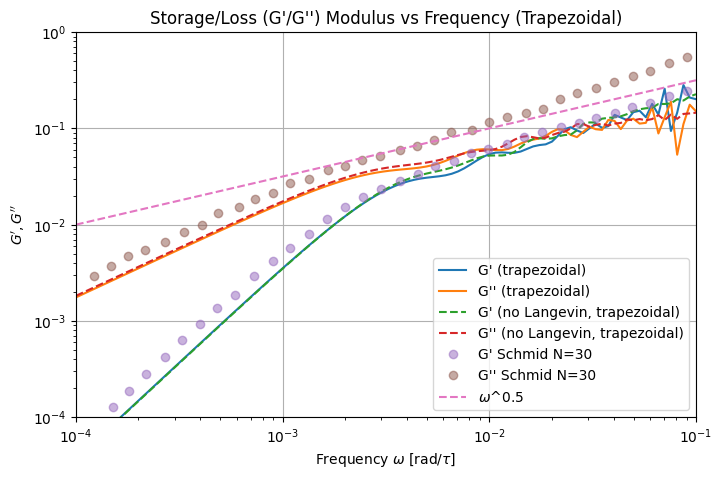

In [185]:
Gp = []
Gpp = []

for ome in omega:
    
    gp = ome * np.trapezoid(prepped_G_t_multitau * np.sin(ome * prepped_time), prepped_time)
    gpp = ome * np.trapezoid(prepped_G_t_multitau * np.cos(ome * prepped_time), prepped_time)
    Gp.append(gp)
    Gpp.append(gpp)

fig = plt.figure(figsize=(8, 5))
plt.xscale('log')
plt.yscale('log')
plt.loglog(omega, Gp, label="G' (trapezoidal)")
plt.loglog(omega, Gpp, label="G'' (trapezoidal)")
plt.loglog(omega, Gp_no_langevin, linestyle='--', label="G' (no Langevin, trapezoidal)")
plt.loglog(omega, Gpp_no_langevin, linestyle='--', label="G'' (no Langevin, trapezoidal)")
plt.loglog(data_schmid_gpgpp['omega_Gp'], data_schmid_gpgpp['Gp'], 'o', label="G' Schmid N=30", alpha=0.5)
plt.loglog(data_schmid_gpgpp['omega_Gpp'],  data_schmid_gpgpp['Gpp'], 'o', label="G'' Schmid N=30", alpha=0.5)
plt.loglog(omega, omega**0.5, linestyle='--', label=f"$\omega$^{0.5}")
plt.xlabel(r'Frequency $\omega$ [rad/$\tau$]')
plt.ylabel("$G', G''$")
plt.xlim([1e-4, 1e-1])
plt.ylim([1e-4, 1e0])
plt.title("Storage/Loss (G'/G'') Modulus vs Frequency (Trapezoidal)")
plt.grid()
plt.legend()
plt.show()